<a href="https://colab.research.google.com/github/badhayearushi-alt/Python---Basic---Projects/blob/main/task_19.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Upload the dataset
from google.colab import files
uploaded = files.upload()

# Read the CSV file
df = pd.read_csv("House Price Prediction Dataset.csv")

# Display first 10 rows
df.head(10)

Saving House Price Prediction Dataset.csv to House Price Prediction Dataset.csv


,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056
5,6,3944,1,2,1,1906,Urban,Poor,No,93262
6,7,3671,1,1,2,1948,Rural,Poor,Yes,448722
7,8,3419,2,4,1,1925,Suburban,Good,Yes,594893
8,9,630,2,2,1,1932,Rural,Poor,Yes,652878
9,10,2185,3,3,1,2000,Downtown,Poor,No,340375


In [ ]:
# Missing values
print(df.isnull().sum())

# Missing value percentage
print((df.isnull().sum()/len(df))*100)

# Fill missing values
df.fillna(df.select_dtypes(include=np.number).mean(), inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Duplicates:", df.duplicated().sum())

Id           0
Area         0
Bedrooms     0
Bathrooms    0
Floors       0
YearBuilt    0
Location     0
Condition    0
Garage       0
Price        0
dtype: int64
Id           0.0
Area         0.0
Bedrooms     0.0
Bathrooms    0.0
Floors       0.0
YearBuilt    0.0
Location     0.0
Condition    0.0
Garage       0.0
Price        0.0
dtype: float64
Duplicates: 0


In [ ]:
df.describe()

print("Minimum:", df["Price"].min())
print("Maximum:", df["Price"].max())
print("Mean:", df["Price"].mean())
print("Median:", df["Price"].median())

Minimum: 50005
Maximum: 999656
Mean: 537676.855
Median: 539254.0


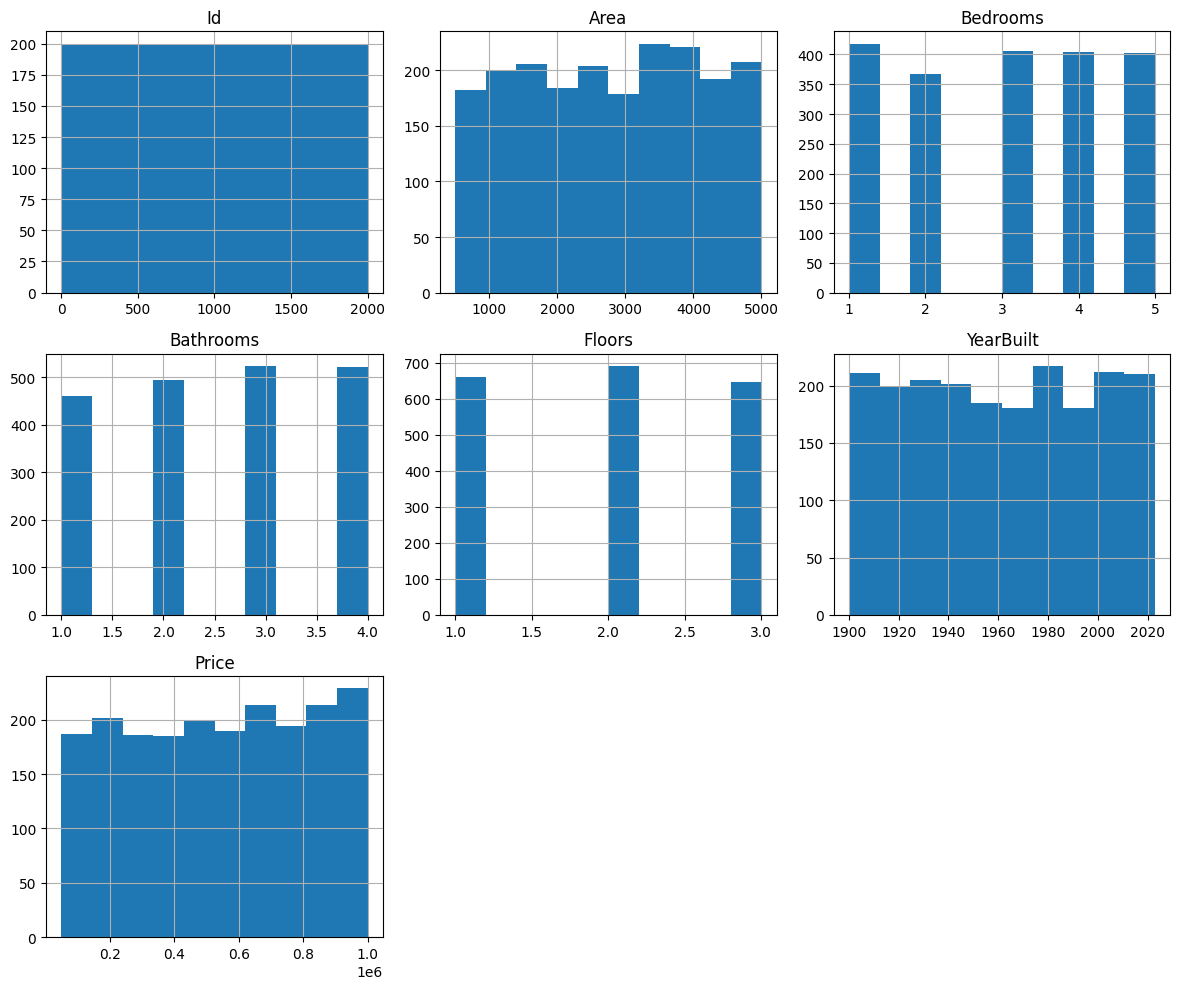

In [ ]:
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

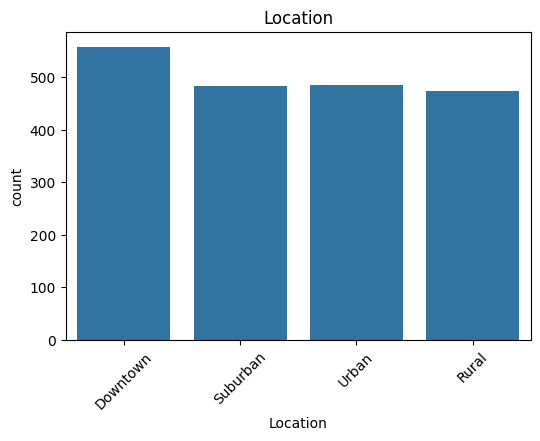

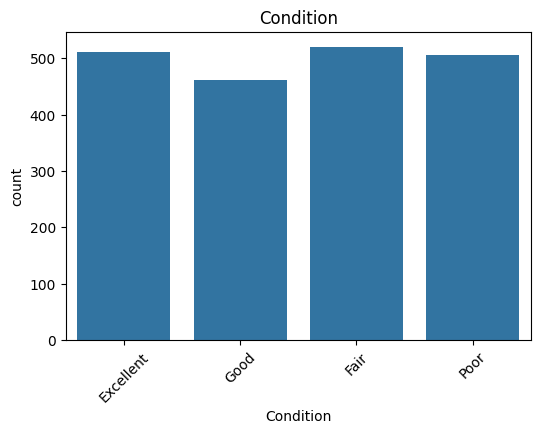

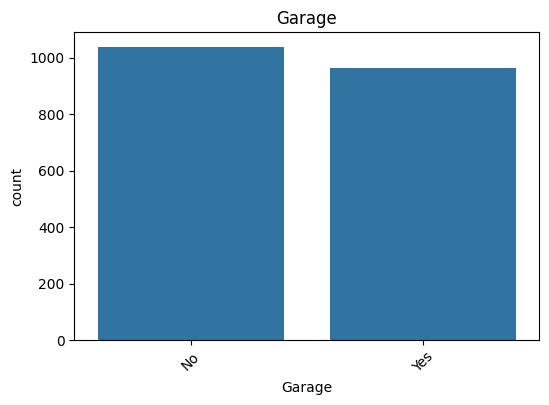

In [ ]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.title(col)
    plt.show()

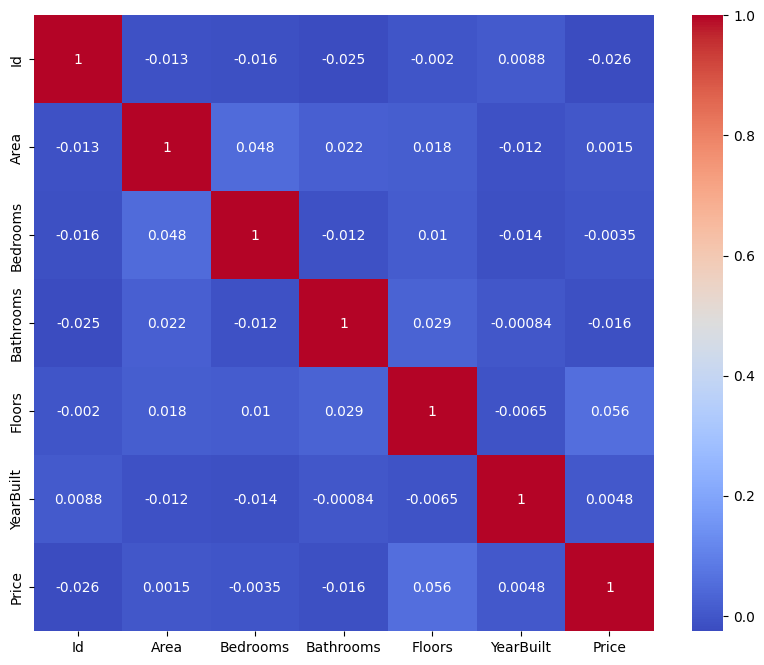

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [ ]:
X = df.drop("Price", axis=1)
y = df["Price"]

print("Independent Features:")
print(X.columns)

print("\nDependent Feature:")
print(y.name)

Independent Features:
Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage'],
      dtype='object')

Dependent Feature:
Price


In [ ]:
df_encoded = pd.get_dummies(df, drop_first=True)

df_encoded.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,1,1360,5,4,3,1970,149919,False,False,False,False,False,False,False
1,2,4272,5,4,3,1958,424998,False,False,False,False,False,False,False
2,3,3592,2,2,3,1938,266746,False,False,False,False,True,False,False
3,4,966,4,2,2,1902,244020,False,True,False,True,False,False,True
4,5,4926,1,4,2,1975,636056,False,False,False,True,False,False,True


In [ ]:
from sklearn.preprocessing import StandardScaler

X = df_encoded.drop("Price", axis=1)
y = df_encoded["Price"]

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location_Rural,Location_Suburban,Location_Urban,Condition_Fair,Condition_Good,Condition_Poor,Garage_Yes
0,-1.731185,-1.101471,1.401791,1.305568,1.244151,0.238155,-0.557329,-0.564262,-0.565802,-0.593519,-0.547307,-0.582739,-0.962695
1,-1.729453,1.147485,1.401791,1.305568,1.244151,-0.095942,-0.557329,-0.564262,-0.565802,-0.593519,-0.547307,-0.582739,-0.962695
2,-1.727721,0.622317,-0.704581,-0.498326,1.244151,-0.652770,-0.557329,-0.564262,-0.565802,-0.593519,1.827127,-0.582739,-0.962695
3,-1.725989,-1.405759,0.699667,-0.498326,0.008035,-1.655061,-0.557329,1.772226,-0.565802,1.684865,-0.547307,-0.582739,1.038750
4,-1.724257,1.652574,-1.406705,1.305568,0.008035,0.377363,-0.557329,-0.564262,-0.565802,1.684865,-0.547307,-0.582739,1.038750
